# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Maria Putu Evelyne Corena Puryatma | 5054251011 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('insurance.csv')

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
for col in ['sex', 'smoker', 'region']:
    print(df[col].value_counts(), '\n')

sex
male      676
female    662
Name: count, dtype: int64 

smoker
no     1064
yes     274
Name: count, dtype: int64 

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64 



## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


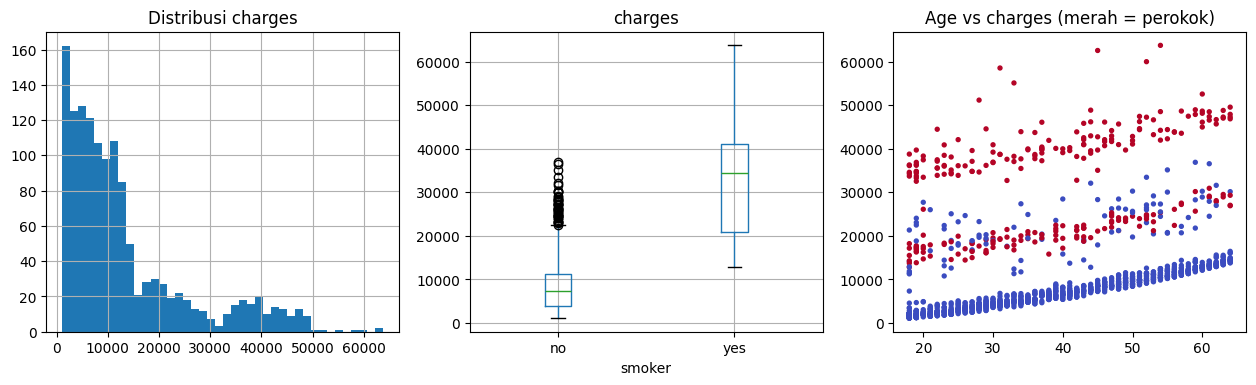

age         0.299008
bmi         0.198341
children    0.067998
charges     1.000000
Name: charges, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['charges'].hist(bins=40, ax=axes[0]); axes[0].set_title('Distribusi charges')
df.boxplot('charges', by='smoker', ax=axes[1])
axes[2].scatter(df['age'], df['charges'], c=(df['smoker'] == 'yes'), cmap='coolwarm', s=8)
axes[2].set_title('Age vs charges (merah = perokok)')
plt.suptitle(''); plt.show()
print(df.corr(numeric_only=True)['charges'])

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [9]:
X = df.drop(columns='charges')
y = df['charges']

In [10]:
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()
print(num_cols, cat_cols)

['age', 'bmi', 'children'] ['sex', 'smoker', 'region']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Versi scaled (untuk Linear, Poly, Ridge, Lasso, SVR) dan versi tanpa scaling (untuk Decision Tree)
prep_scaled = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)])
prep_tree = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)])

X_train_s = prep_scaled.fit_transform(X_train)
X_test_s = prep_scaled.transform(X_test)
X_train_t = prep_tree.fit_transform(X_train)
X_test_t = prep_tree.transform(X_test)

# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [13]:
lr = LinearRegression().fit(X_train_s, y_train)

In [14]:
pred_lr = lr.predict(X_test_s)

## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [15]:
# Degree dipilih dengan cross-validation (1-3)
poly_cv = GridSearchCV(
    make_pipeline(PolynomialFeatures(include_bias=False), LinearRegression()),
    {'polynomialfeatures__degree': [1, 2, 3]}, cv=5, scoring='r2').fit(X_train_s, y_train)
print(poly_cv.best_params_, poly_cv.best_score_)
poly = poly_cv.best_estimator_

{'polynomialfeatures__degree': 2} 0.8268445143163377


In [16]:
pred_poly = poly.predict(X_test_s)

## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [17]:
# Alpha dipilih dengan cross-validation
ridge_cv = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1, 10, 100]}, cv=5, scoring='r2').fit(X_train_s, y_train)
print(ridge_cv.best_params_, ridge_cv.best_score_)
ridge = ridge_cv.best_estimator_

{'alpha': 1} 0.7331521431579194


In [18]:
pred_ridge = ridge.predict(X_test_s)

## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [19]:
lasso_cv = GridSearchCV(Lasso(max_iter=10000), {'alpha': [0.01, 0.1, 1, 10, 100]}, cv=5, scoring='r2').fit(X_train_s, y_train)
print(lasso_cv.best_params_, lasso_cv.best_score_)
lasso = lasso_cv.best_estimator_

{'alpha': 100} 0.7342433365588266


In [20]:
pred_lasso = lasso.predict(X_test_s)

## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [21]:
tree_cv = GridSearchCV(DecisionTreeRegressor(random_state=42),
                       {'max_depth': [2, 3, 4, 5, 6, 8], 'min_samples_leaf': [1, 5, 10, 20, 40]},
                       cv=5, scoring='r2').fit(X_train_t, y_train)
print(tree_cv.best_params_, tree_cv.best_score_)
tree = tree_cv.best_estimator_

{'max_depth': 5, 'min_samples_leaf': 40} 0.8393162890704341


In [22]:
pred_tree = tree.predict(X_test_t)

## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [23]:
# Target di-scale agar SVR bisa belajar dengan baik (charges bernilai puluhan ribu)
y_mean, y_std = y_train.mean(), y_train.std()
svr_cv = GridSearchCV(SVR(), {'C': [0.1, 1, 10, 100], 'epsilon': [0.01, 0.1], 'gamma': ['scale', 0.01, 0.1]},
                      cv=5, scoring='r2').fit(X_train_s, (y_train - y_mean) / y_std)
print(svr_cv.best_params_, svr_cv.best_score_)
svr = svr_cv.best_estimator_

{'C': 10, 'epsilon': 0.1, 'gamma': 0.1} 0.8340063157420138


In [24]:
pred_svr = svr.predict(X_test_s) * y_std + y_mean

# 4. Evaluasi Model

In [25]:
preds = {'Linear Regression': pred_lr, 'Polynomial Regression': pred_poly, 'Ridge': pred_ridge,
         'Lasso': pred_lasso, 'Decision Tree': pred_tree, 'SVR': pred_svr}
results = pd.DataFrame({
    name: {'MAE': mean_absolute_error(y_test, p), 'MSE': mean_squared_error(y_test, p),
           'RMSE': np.sqrt(mean_squared_error(y_test, p)), 'R2': r2_score(y_test, p)}
    for name, p in preds.items()}).T
results.round(3)

,MAE,MSE,RMSE,R2
Linear Regression,4181.194,3.359692e+07,5796.285,0.784
Polynomial Regression,2729.500,2.071281e+07,4551.132,0.867
Ridge,4193.195,3.364539e+07,5800.465,0.783
Lasso,4248.492,3.426606e+07,5853.722,0.779
Decision Tree,2811.686,2.225990e+07,4718.040,0.857
SVR,2387.286,2.031935e+07,4507.699,0.869


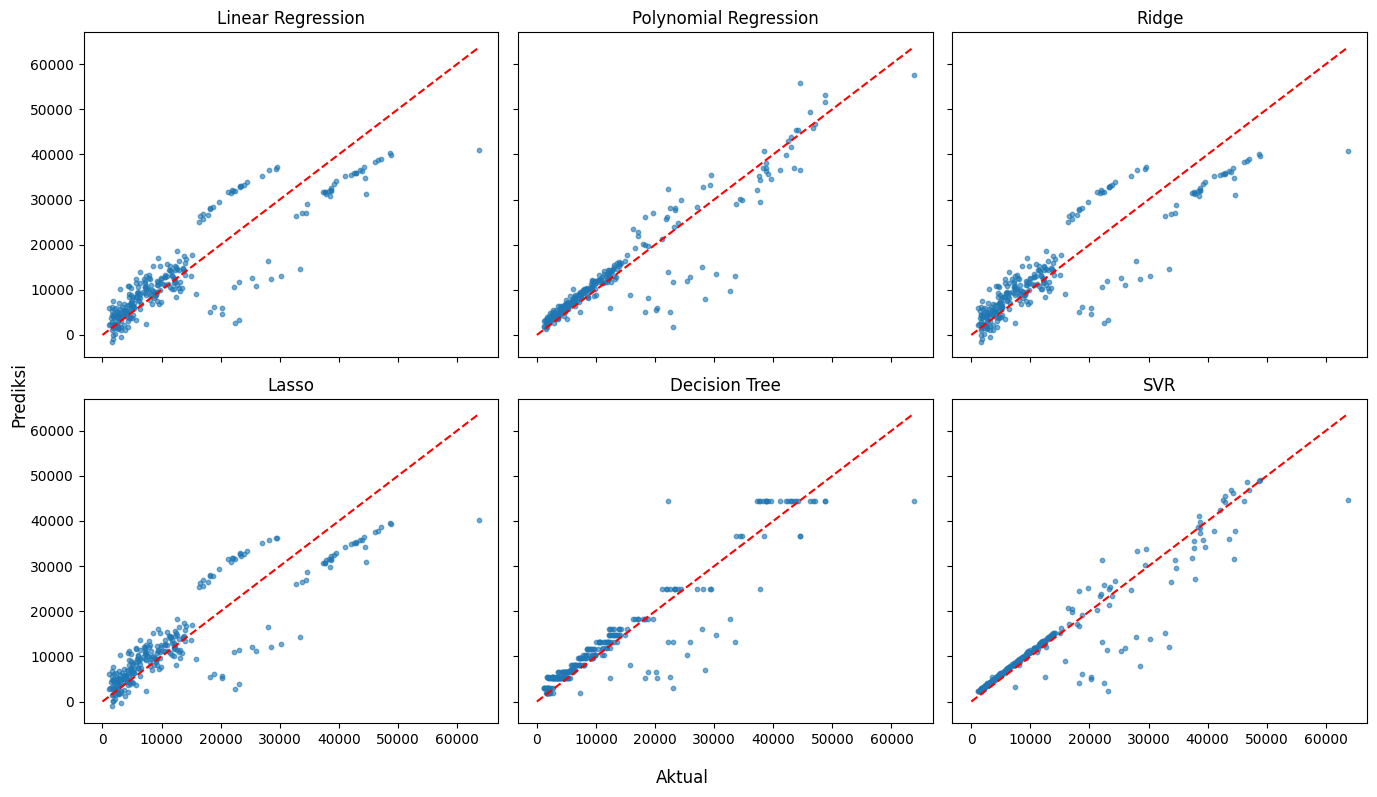

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for ax, (name, p) in zip(axes.ravel(), preds.items()):
    ax.scatter(y_test, p, s=10, alpha=0.6)
    ax.plot([0, y.max()], [0, y.max()], 'r--')
    ax.set_title(name)
fig.supxlabel('Aktual'); fig.supylabel('Prediksi')
plt.tight_layout(); plt.show()

# 5. Analisis
## Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.

| Model | MAE | RMSE | R² | Parameter terpilih |
|---|---|---|---|---|
| Linear Regression | 4181 | 5796 | 0.784 | - |
| Polynomial Regression | 2730 | 4551 | 0.867 | degree = 2 |
| Ridge | 4193 | 5800 | 0.783 | alpha = 1 |
| Lasso | 4248 | 5854 | 0.779 | alpha = 100 |
| Decision Tree | 2812 | 4718 | 0.857 | max_depth = 5, min_samples_leaf = 40 |
| SVR | 2387 | 4508 | 0.869 | C = 10, epsilon = 0.1, gamma = 0.1 |

- **Model linear (Linear, Ridge, Lasso)** hasilnya hampir sama (R² ~0.78). Regularisasi tidak membantu karena fiturnya hanya sedikit dan tidak ada overfitting; masalahnya ada pada model yang terlalu sederhana (underfitting). Lasso sedikit lebih buruk karena alpha terbaik berada di batas grid (100), jadi koefisien mulai terlalu ditekan.
- **Model non-linear (Polynomial, Decision Tree, SVR)** jauh lebih baik (R² 0.86-0.87, RMSE turun sekitar 1.100-1.300). Ini karena `charges` punya hubungan non-linear dan interaksi antar fitur, terutama `smoker` dengan `age` dan `bmi` (terlihat di EDA: perokok punya biaya jauh lebih tinggi).
- **SVR** terbaik pada semua metrik, dengan MAE paling kecil. Ini bergantung pada scaling fitur dan scaling target; tanpa itu SVR dengan `charges` bernilai puluhan ribu tidak akan belajar dengan baik. Polynomial degree 2 hampir sama baik dengan model yang jauh lebih sederhana.
- **Decision Tree** tidak membutuhkan scaling. Parameter yang dipilih (`min_samples_leaf` = 40) menunjukkan pohon perlu dibatasi agar tidak overfitting. Prediksinya berbentuk bertingkat sehingga kurang halus dibanding SVR.
- **Pengaruh parameter:** degree 2 optimal untuk Polynomial (degree yang lebih tinggi menyebabkan overfitting/tidak stabil); alpha pada Ridge/Lasso hampir tidak mengubah hasil; kedalaman dan ukuran daun menentukan kompleksitas Decision Tree.
- Selisih SVR, Polynomial, dan Decision Tree kecil, sehingga perbedaan antar ketiganya belum tentu signifikan pada satu kali split data.


# 6. Kesimpulan dan Saran
## Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.

**Kesimpulan**
- SVR adalah model terbaik (R² 0.869, RMSE 4508), diikuti Polynomial Regression degree 2 (R² 0.867) dan Decision Tree (R² 0.857).
- Linear, Ridge, dan Lasso menghasilkan R² sekitar 0.78 karena tidak dapat menangkap hubungan non-linear dan interaksi fitur.
- Data perlu di-scaling untuk model berbasis jarak/gradien (terutama SVR), sedangkan Decision Tree tidak memerlukannya.

**Saran**
- Tambahkan fitur interaksi atau fitur turunan, misalnya `smoker` x `bmi`, `smoker` x `age`, dan kategori `bmi >= 30`, agar model linear ikut membaik.
- Coba model ensemble seperti Random Forest atau Gradient Boosting.
- Gunakan grid parameter yang lebih luas (alpha Lasso di batas grid) dan cross-validation berulang agar perbandingan antar model lebih andal.
